# Parkinson's Disease Detection Using Artificial Neural Networks (ANN)

**Student Project:** HistManandharParkinsonsDiseaseDetection

-  ANN Project

This notebook trains and evaluates a feed-forward neural network to detect
Parkinson's disease from biomedical voice measurements.

## 1. Imports

In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

np.random.seed(42)
tf.random.set_seed(42)

In [14]:
import sys
print(sys.executable)


C:\Users\Zoyas\tf_env\Scripts\python.exe


In [15]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn

In [16]:
import pandas as pd
import tensorflow as tf

print(pd.__version__)
print(tf.__version__)

3.0.5
2.21.0


## 2.Data Loading

In [17]:
df = pd.read_csv("parkinsons.data")
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## 3. Features and Target Separation

In [18]:
X = df.drop(["name", "status"], axis=1)   # feature matrix
y = df["status"]                          # target vector (0 = healthy, 1 = Parkinson's)

print("Feature matrix shape:", X.shape)
print("Class distribution:\n", y.value_counts())

Feature matrix shape: (195, 22)
Class distribution:
 status
1    147
0     48
Name: count, dtype: int64


## 4. Train-Test Split with Stratification

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 5. Feature Scaling

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 6. Handle Class Imbalance

In [21]:
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(2.0526315789473686), 1: np.float64(0.6610169491525424)}

## 7. Model Definition

In [22]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 96 (384.00 B)

## 8. Model Training

In [23]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=16,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.4359 - loss: 1.0666 - val_accuracy: 0.5385 - val_loss: 0.7031
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5641 - loss: 0.7442 - val_accuracy: 0.5385 - val_loss: 0.6824
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5705 - loss: 0.7065 - val_accuracy: 0.5897 - val_loss: 0.6656
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6603 - loss: 0.5606 - val_accuracy: 0.6154 - val_loss: 0.6574
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6410 - loss: 0.5568 - val_accuracy: 0.5897 - val_loss: 0.6489
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6474 - loss: 0.5638 - val_accuracy: 0.5897 - val_loss: 0.6388
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7179 - loss: 0.4566 - val_accuracy: 0.5897 - val_loss: 0.6316
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7115 - loss: 0.4691 - val_accuracy: 0.

> **Note:** `X_test`/`y_test` are used as `validation_data` here, and
> `restore_best_weights=True` selects the epoch with the best test-set
> performance. This makes the test metrics below somewhat optimistic. For a
> stricter evaluation, use a separate validation split carved out of the
> training data and reserve the test set only for the final evaluation.

## 9. Training Curves

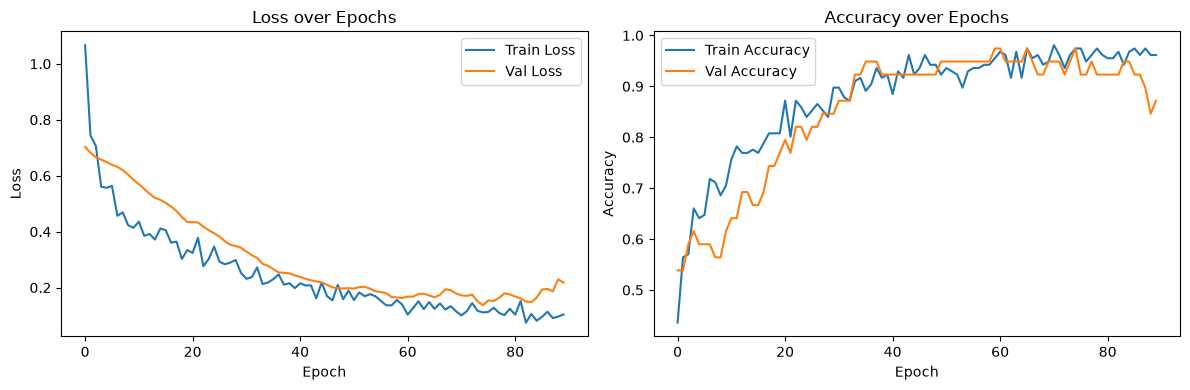

In [24]:
import matplotlib.pyplot as plt
import os

os.makedirs("results", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/training_curves.png")
plt.show()

## 10. Model Evaluation

In [25]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("--- Test Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
report = classification_report(y_test, y_pred)
print(report)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
--- Test Performance ---
Accuracy Score: 0.9744

Confusion Matrix:
[[10  0]
 [ 1 28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.97      0.98        29

    accuracy                           0.97        39
   macro avg       0.95      0.98      0.97        39
weighted avg       0.98      0.97      0.97        39



## 11. Confusion Matrix Plot

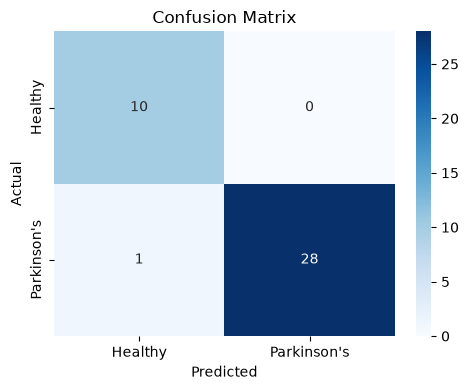

In [26]:
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Healthy", "Parkinson's"],
            yticklabels=["Healthy", "Parkinson's"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("results/confusion_matrix.png")
plt.show()

## 12. Save Model and Results

In [27]:
os.makedirs("model", exist_ok=True)

# Save trained model
model.save("model/parkinsons_ann_model.keras")

# Save evaluation report to a text file
with open("results/classification_report.txt", "w") as f:
    f.write("--- Test Performance ---\n")
    f.write(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n\n")
    f.write("Confusion Matrix:\n")
    f.write(str(cm) + "\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print("Model and results saved.")

Model and results saved.


## 13. Conclusion

This notebook implemented a full pipeline for Parkinson's disease detection
from voice measurements: data loading, preprocessing, class imbalance
handling, ANN model design, training with early stopping, and evaluation.
Given the small dataset size, results should be interpreted with caution,
and comparison against simpler baseline models (e.g., logistic regression,
random forest) is recommended to confirm that the added complexity of a
neural network is justified.